# mapcv Tutorial  -  Amsterdam Satellite Segmentation Dataset

This notebook walks through the full **mapcv** workflow end-to-end using publicly available
data from Amsterdam, Netherlands:

* **Demo 1  -  Binary segmentation**: building footprints (Jordaan neighbourhood, zoom 17)
* **Demo 2  -  Multiclass segmentation**: land use polygons (canal ring, zoom 15)

Label data: (c) OpenStreetMap contributors, [ODbL](https://www.openstreetmap.org/copyright).  
Imagery: Esri World Imagery (Esri, Maxar, Earthstar Geographics).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from mapcv import (
    parse_geojson,
    rasterize,
    sample_patches,
    stitch_region,
    transform_to_mercator,
    SamplerConfig,
)

DATA = Path("../data")  # relative to this notebook

---
## Demo 1  -  Binary Building Segmentation

The Jordaan is one of Amsterdam's most densely built historic neighbourhoods.
At zoom 17 (~ 1.2 m/px) each building is clearly visible.

**Workflow**
1. Load building footprints from GeoJSON
2. Download satellite tiles and stitch into one image
3. Rasterize footprints onto the image grid
4. Sample non-overlapping 256 x 256 patches

In [2]:
# Bounding box: Jordaan heart (WGS-84)
WEST, SOUTH, EAST, NORTH = 4.883, 52.371, 4.896, 52.378
ZOOM = 17

# 1. Parse building footprints
bldg_bytes = (DATA / "amsterdam_buildings.geojson").read_bytes()
bldg_geoms, bldg_class_map = parse_geojson(bldg_bytes)  # all get class_id=1
print(f"{len(bldg_geoms)} building polygons")

506 building polygons


In [3]:
# 2. Download and stitch satellite tiles (takes ~10 s on a fast connection)
image, transform = stitch_region(
    west=WEST,
    south=SOUTH,
    east=EAST,
    north=NORTH,
    zoom=ZOOM,
    source="esri_satellite",
)
H, W = image.shape[:2]
print(f"Stitched image: {W} x {H} px")

Fetching 30 tiles... done.


30/30 tiles fetched, 0 failed

Stitched image: 1536 x 1280 px


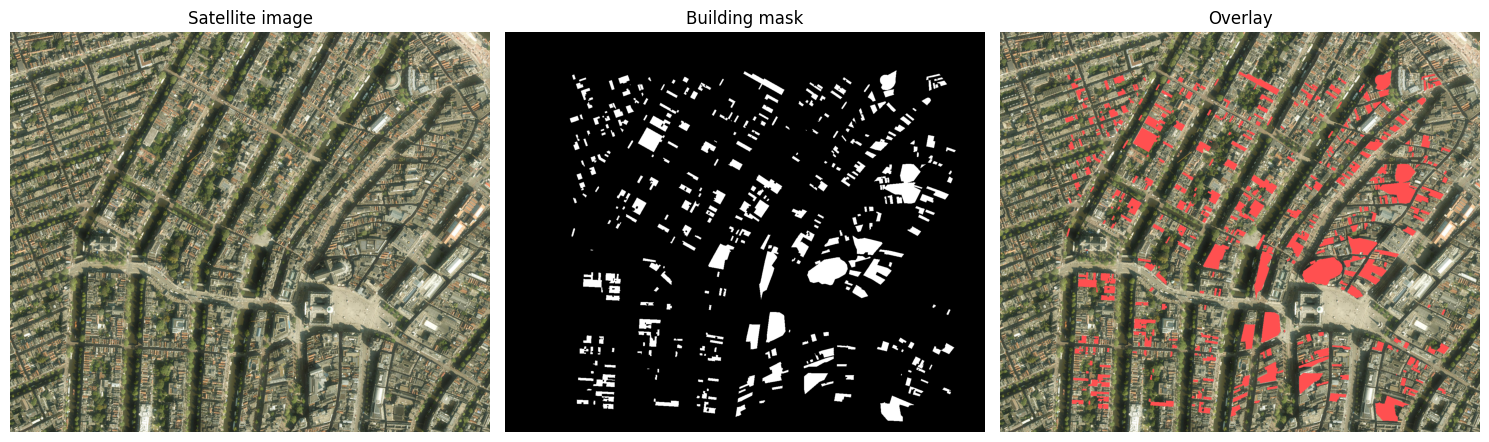

In [4]:
# 3. Rasterize: project footprints to Web Mercator, burn onto image grid
merc_geoms = [(transform_to_mercator(g), cid) for g, cid in bldg_geoms]
bldg_mask = rasterize(merc_geoms, out_shape=(H, W), transform=transform)

# Quick visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Satellite image")
axes[1].imshow(bldg_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Building mask")
overlay = image.copy()
overlay[bldg_mask == 1] = [255, 80, 80]
axes[2].imshow(overlay)
axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

30 patches


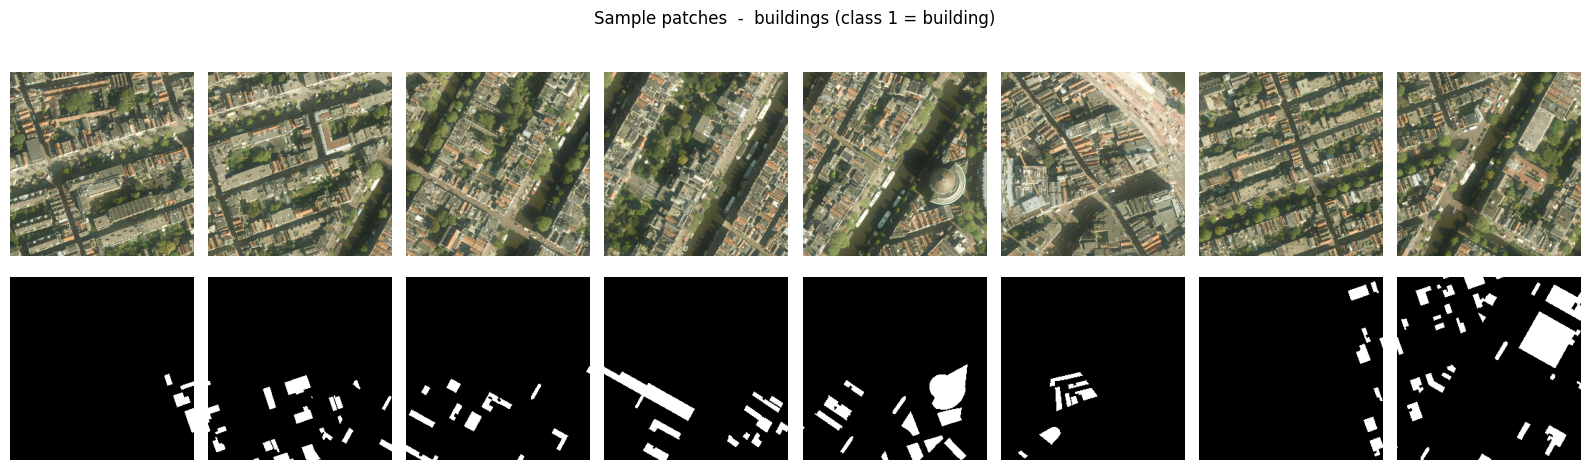

In [5]:
# 4. Sample 256x256 patches (drop incomplete edge patches)
cfg = SamplerConfig(patch_size=256, edge_strategy="drop", max_empty_ratio=0.95)
patch_imgs, patch_masks, meta = sample_patches(image, bldg_mask, cfg)
print(f"{len(meta)} patches")

# Show first 8 patch pairs
n = min(8, len(meta))
fig, axes = plt.subplots(2, n, figsize=(2 * n, 5))
for i in range(n):
    axes[0, i].imshow(patch_imgs[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(patch_masks[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Image", fontsize=10)
axes[1, 0].set_ylabel("Mask", fontsize=10)
plt.suptitle("Sample patches  -  buildings (class 1 = building)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Demo 2  -  Multiclass Land Use Segmentation

At zoom 15 (~ 4.8 m/px) the urban structure of the canal ring is visible:
water bodies, parks, residential blocks, and commercial zones.

`parse_geojson` assigns integer class IDs in the order it first encounters each class name.
The returned `class_map` dict tells you the exact `name -> id` mapping so you can build a
consistent colour palette regardless of encounter order.

In [6]:
# Wider bounding box covering the full land-use dataset extent
LU_WEST, LU_SOUTH, LU_EAST, LU_NORTH = 4.864, 52.360, 4.922, 52.386
LU_ZOOM = 15

# Parse land use polygons  -  class names come from the 'class' string property
lu_bytes = (DATA / "amsterdam_landuse.geojson").read_bytes()
lu_geoms, class_map = parse_geojson(lu_bytes, label_field="class")
# class_map: {class_name -> class_id}, IDs assigned by encounter order
print("Class map:", class_map)
print(f"{len(lu_geoms)} land use polygons")

Class map: {'commercial': 1, 'residential': 2, 'water': 3, 'park': 4}
189 land use polygons


In [7]:
# Download and stitch at zoom 15
lu_image, lu_transform = stitch_region(
    west=LU_WEST,
    south=LU_SOUTH,
    east=LU_EAST,
    north=LU_NORTH,
    zoom=LU_ZOOM,
    source="esri_satellite",
)
LU_H, LU_W = lu_image.shape[:2]
print(f"Stitched image: {LU_W} x {LU_H} px")

Fetching 35 tiles... done.


35/35 tiles fetched, 0 failed

Stitched image: 1792 x 1280 px


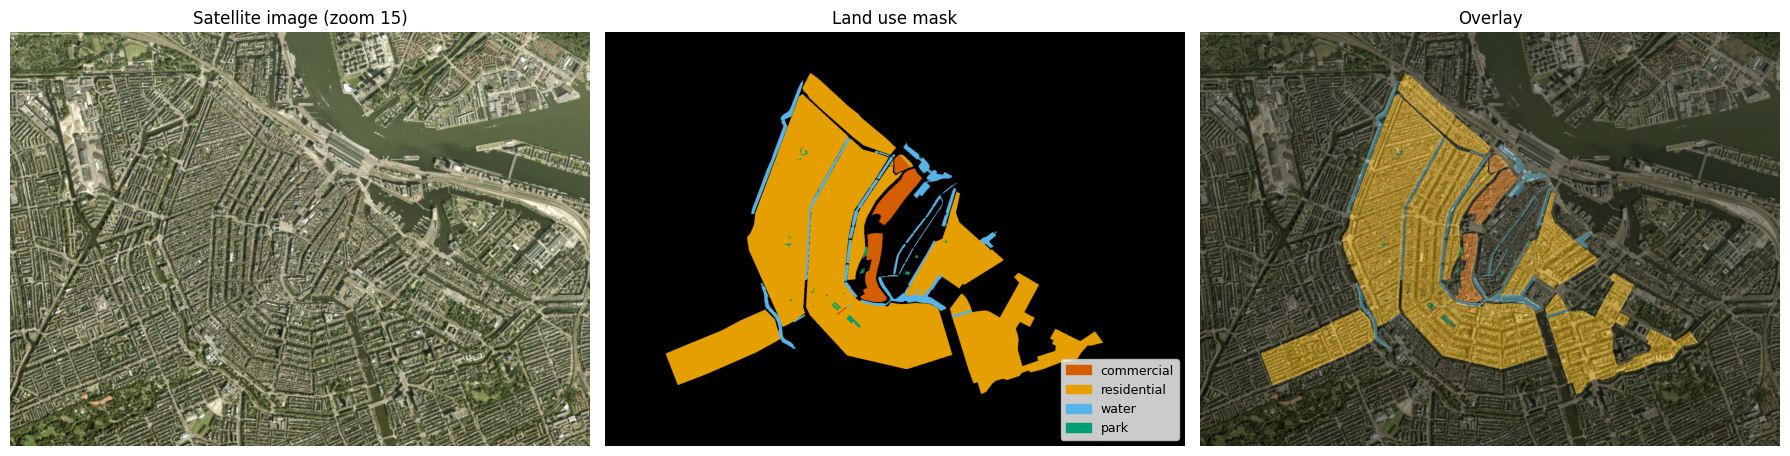

In [8]:
# Rasterize multiclass mask
lu_merc = [(transform_to_mercator(g), cid) for g, cid in lu_geoms]
lu_mask = rasterize(lu_merc, out_shape=(LU_H, LU_W), transform=lu_transform)

# Build palette from class_map (works for any encounter order)
COLORS = {
    "residential": [230, 159, 0],
    "commercial": [213, 94, 0],
    "park": [0, 158, 115],
    "water": [86, 180, 233],
}
max_id = max(class_map.values())
PALETTE = np.zeros((max_id + 1, 3), dtype=np.uint8)  # 0 = background (black)
for name, cid in class_map.items():
    if name in COLORS:
        PALETTE[cid] = COLORS[name]

coloured = PALETTE[lu_mask]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(lu_image)
axes[0].set_title("Satellite image (zoom 15)")
axes[1].imshow(coloured)
axes[1].set_title("Land use mask")

alpha = 0.45
blend = (
    (lu_image.astype(float) * (1 - alpha) + coloured.astype(float) * alpha)
    .clip(0, 255)
    .astype(np.uint8)
)
axes[2].imshow(blend)
axes[2].set_title("Overlay")

legend_patches = [
    mpatches.Patch(color=np.array(COLORS[name]) / 255, label=name)
    for name in class_map
    if name in COLORS
]
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

12 / 35 patches have >= 15% labeled pixels


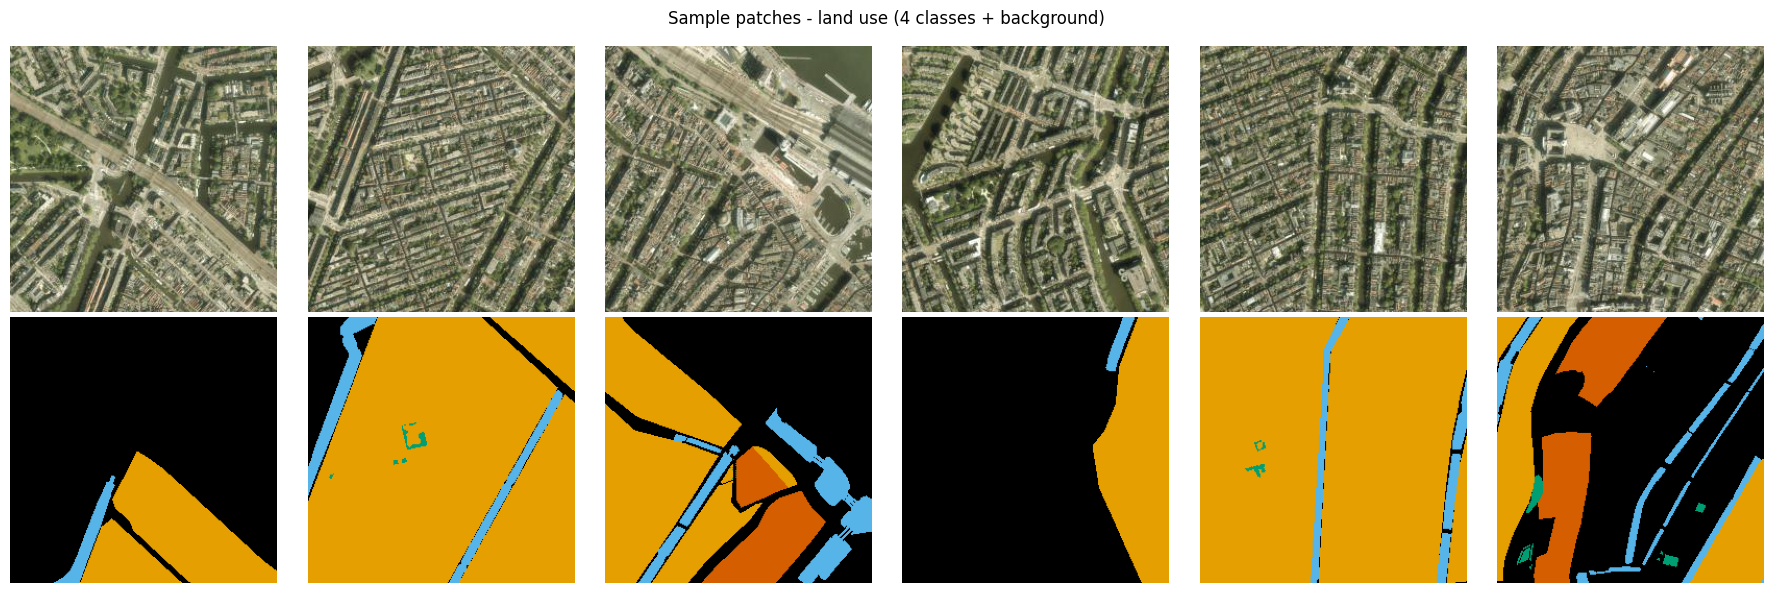

In [9]:
# Sample 256x256 patches
lu_cfg = SamplerConfig(patch_size=256, edge_strategy="drop")
lu_patch_imgs, lu_patch_masks, lu_meta = sample_patches(lu_image, lu_mask, lu_cfg)

# Filter by mask coverage, keeping patches where at least 15% of pixels have a label, for demonstration purposes
labeled_ratio = np.array([np.sum(m > 0) / m.size for m in lu_patch_masks])
keep = np.where(labeled_ratio >= 0.15)[0]
print(f"{len(keep)} / {len(lu_meta)} patches have >= 15% labeled pixels")
lu_patch_imgs = lu_patch_imgs[keep]
lu_patch_masks = lu_patch_masks[keep]

# Show first 6 patch pairs
n = min(6, len(lu_patch_imgs))
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
for i in range(n):
    axes[0, i].imshow(lu_patch_imgs[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(PALETTE[lu_patch_masks[i]])
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Image", fontsize=10)
axes[1, 0].set_ylabel("Mask", fontsize=10)
plt.suptitle("Sample patches - land use (4 classes + background)", fontsize=12)
plt.tight_layout()
plt.show()

---
## What's next?

* **Save patches to disk**  -  use `write_patches` + `Manifest` to write PNG files and a JSON manifest.
* **Train/val/test split**  -  use `split_dataset` to stratify the manifest into splits.
* **Custom tile source**  -  pass any XYZ URL template to `stitch_region` via `url_template=`.
* **Large regions**  -  use `download_region_strips` to process areas that don't fit in RAM.
* **KML labels**  -  `parse_kml` accepts KML bytes directly, same interface as `parse_geojson`.